In [10]:
import pandas as pd

In [11]:
data = {
    'Height': [170, 165, 180, 175, 160, 172, 168, 177, 162, 158],
    'Weight': [65, 59, 75, 68, 55, 70, 62, 74, 58, 54],
    'Age': [30, 25, 35, 28, 22, 32, 27, 33, 24, 21],
    'Gender': [1, 0, 1, 1, 0, 1, 0, 1, 0, 0]  # 1 = Male, 0 = Female
}
df = pd.DataFrame(data)

df

,Height,Weight,Age,Gender
0,170,65,30,1
1,165,59,25,0
2,180,75,35,1
3,175,68,28,1
4,160,55,22,0
5,172,70,32,1
6,168,62,27,0
7,177,74,33,1
8,162,58,24,0
9,158,54,21,0


# Standardizing the Data

Since the features have different scales Height vs Age we standardize the data. This makes all features have mean = 0 and standard deviation = 1 so that no feature dominates just because of its units.

In [12]:
from sklearn.preprocessing import StandardScaler

X = df.drop('Gender', axis=1)
y = df['Gender']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
X_scaled

array([[ 0.18419807,  0.13867505,  0.50910379],
       [-0.52425605, -0.69337525, -0.59764358],
       [ 1.60110632,  1.52542554,  1.61585117],
       [ 0.8926522 ,  0.5547002 ,  0.06640484],
       [-1.23271018, -1.24807544, -1.26169201],
       [ 0.46757972,  0.83205029,  0.95180275],
       [-0.09918358, -0.2773501 , -0.15494463],
       [ 1.17603385,  1.38675049,  1.17315222],
       [-0.94932853, -0.83205029, -0.81899306],
       [-1.51609183, -1.38675049, -1.48304149]])

# Applying Principal Component Analysis (PCA) algorithm

- We reduce the data from 3 features to 2 new features called principal components. These components capture most of the original information but in fewer dimensions.
- We split the data into 70% training and 30% testing sets.
- We train a logistic regression model on the reduced training data and predict gender labels on the test set.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluating with Confusion Matrix

The confusion matrix compares actual vs predicted labels. This makes it easy to see where predictions were correct or wrong.

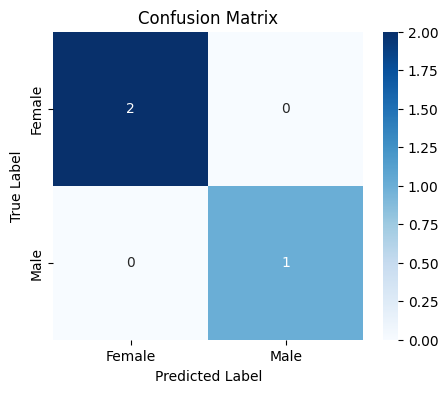

In [15]:
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Female', 'Male'], yticklabels=['Female', 'Male'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

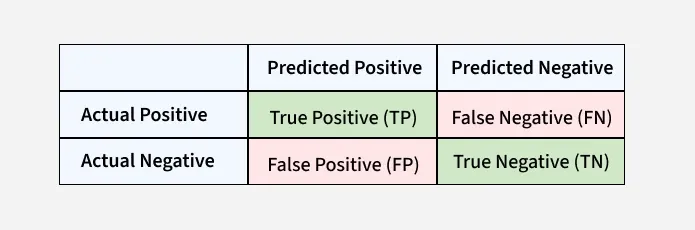

- True Positive (TP): The model correctly predicted a positive outcome i.e the actual outcome was positive.
- True Negative (TN): The model correctly predicted a negative outcome i.e the actual outcome was negative.
- False Positive (FP): The model incorrectly predicted a positive outcome i.e the actual outcome was negative. It is also known as a Type I error.
- False Negative (FN): The model incorrectly predicted a negative outcome i.e the actual outcome was positive. It is also known as a Type II error.

https://www.geeksforgeeks.org/machine-learning/confusion-matrix-machine-learning/

# Visualizing PCA Result

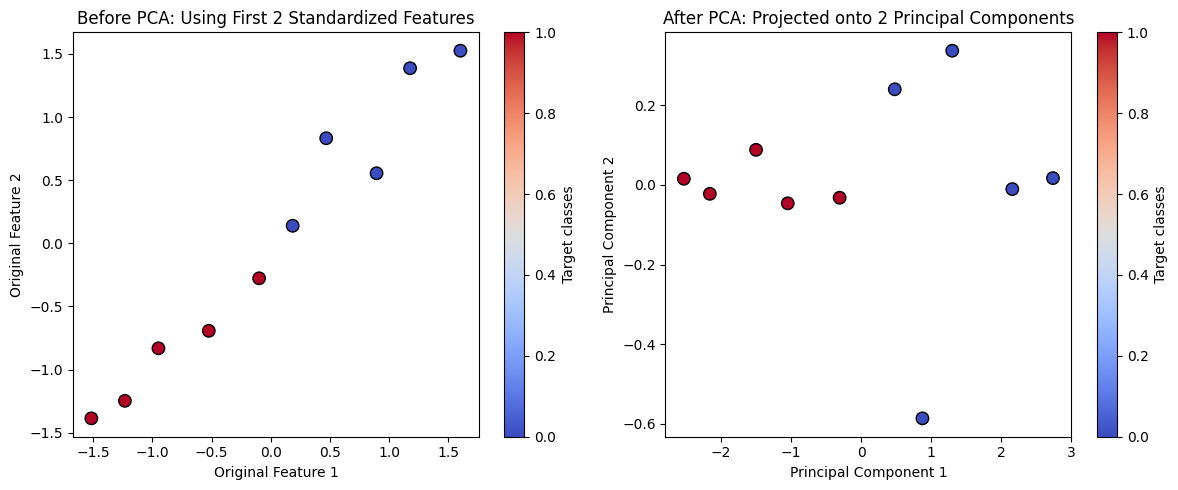

In [16]:
y_numeric = pd.factorize(y)[0]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Original Feature 1')
plt.ylabel('Original Feature 2')
plt.title('Before PCA: Using First 2 Standardized Features')
plt.colorbar(label='Target classes')

plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('After PCA: Projected onto 2 Principal Components')
plt.colorbar(label='Target classes')

plt.tight_layout()
plt.show()

Left Plot Before PCA: This shows the original standardized data plotted using the first two features. There is no guarantee of clear separation between classes as these are raw input dimensions.

Right Plot After PCA: This displays the transformed data using the top 2 principal components. These new components capture the maximum variance often showing better class separation and structure making it easier to analyze or model.